##### Problem Statement
The Marketing department of Adventure Works Cycles wants to increase sales by targeting specific 
customers for a mailing campaign. The company's database contains a list of past customers and a list of 
potential new customers. By investigating the attributes of previous bike buyers, the company hopes to 
discover patterns that they can then apply to potential customers. They hope to use the discovered patterns 
to predict which potential customers are most likely to purchase a bike from Adventure Works Cycles. 

#### Importing Data

In [1]:
import pandas as pd
df = pd.read_csv("./Data/AWCustomers.csv")
df.head()

,CustomerID,Title,FirstName,MiddleName,LastName,Suffix,AddressLine1,AddressLine2,City,StateProvinceName,...,Education,Occupation,Gender,MaritalStatus,HomeOwnerFlag,NumberCarsOwned,NumberChildrenAtHome,TotalChildren,YearlyIncome,LastUpdated
0,21173,NaN,Chad,C,Yuan,NaN,7090 C. Mount Hood,NaN,Wollongong,New South Wales,...,Bachelors,Clerical,M,M,1,3,0,1,81916,2017-03-06
1,13249,NaN,Ryan,NaN,Perry,NaN,3651 Willow Lake Rd,NaN,Shawnee,British Columbia,...,Partial College,Clerical,M,M,1,2,1,2,81076,2017-03-06
2,29350,NaN,Julia,NaN,Thompson,NaN,1774 Tice Valley Blvd.,NaN,West Covina,California,...,Bachelors,Clerical,F,S,0,3,0,0,86387,2017-03-06
3,13503,NaN,Theodore,NaN,Gomez,NaN,2103 Baldwin Dr,NaN,Liverpool,England,...,Partial College,Skilled Manual,M,M,1,2,1,2,61481,2017-03-06
4,22803,NaN,Marshall,J,Shan,NaN,Am Gallberg 234,NaN,Werne,Nordrhein-Westfalen,...,Partial College,Skilled Manual,M,S,1,1,0,0,51804,2017-03-06


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18361 entries, 0 to 18360
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   CustomerID            18361 non-null  int64 
 1   Title                 101 non-null    object
 2   FirstName             18361 non-null  object
 3   MiddleName            10572 non-null  object
 4   LastName              18361 non-null  object
 5   Suffix                3 non-null      object
 6   AddressLine1          18361 non-null  object
 7   AddressLine2          311 non-null    object
 8   City                  18361 non-null  object
 9   StateProvinceName     18361 non-null  object
 10  CountryRegionName     18361 non-null  object
 11  PostalCode            18361 non-null  object
 12  PhoneNumber           18361 non-null  object
 13  BirthDate             18361 non-null  object
 14  Education             18361 non-null  object
 15  Occupation            18361 non-null

In [3]:
### we can remove columns 1-7,11,12,23 as they seem unnecessary
column_indices_to_drop = [1,2,3,4,5,6,7,11,12,23]
df_columns_to_drop = [df.columns[i] for i in column_indices_to_drop]
new_df = df.drop(df_columns_to_drop,axis=1)
new_df.head()

,CustomerID,City,StateProvinceName,CountryRegionName,BirthDate,Education,Occupation,Gender,MaritalStatus,HomeOwnerFlag,NumberCarsOwned,NumberChildrenAtHome,TotalChildren,YearlyIncome
0,21173,Wollongong,New South Wales,Australia,1987-11-13,Bachelors,Clerical,M,M,1,3,0,1,81916
1,13249,Shawnee,British Columbia,Canada,1972-07-21,Partial College,Clerical,M,M,1,2,1,2,81076
2,29350,West Covina,California,United States,1985-11-09,Bachelors,Clerical,F,S,0,3,0,0,86387
3,13503,Liverpool,England,United Kingdom,1977-10-18,Partial College,Skilled Manual,M,M,1,2,1,2,61481
4,22803,Werne,Nordrhein-Westfalen,Germany,1975-02-05,Partial College,Skilled Manual,M,S,1,1,0,0,51804


Customer ID: Discrete
City: Nominal
State: Nominal
Country: Nominal
Birthdate: Date [can be converted to continous age]
Education: Ordinal
Occupation: Ordinal
Gender: Nominal
Marital Status: Nominal
HomeOwnerFlag: Binary 
Number of Cars Owned: Discrete Numerical
Total Children: Discrete Numerical
Yearly Income: Continous



In [4]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18361 entries, 0 to 18360
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   CustomerID            18361 non-null  int64 
 1   City                  18361 non-null  object
 2   StateProvinceName     18361 non-null  object
 3   CountryRegionName     18361 non-null  object
 4   BirthDate             18361 non-null  object
 5   Education             18361 non-null  object
 6   Occupation            18361 non-null  object
 7   Gender                18361 non-null  object
 8   MaritalStatus         18361 non-null  object
 9   HomeOwnerFlag         18361 non-null  int64 
 10  NumberCarsOwned       18361 non-null  int64 
 11  NumberChildrenAtHome  18361 non-null  int64 
 12  TotalChildren         18361 non-null  int64 
 13  YearlyIncome          18361 non-null  int64 
dtypes: int64(6), object(8)
memory usage: 2.0+ MB


Null Values

In [5]:
new_Df_columns = new_df.columns
for column in new_Df_columns:
    print(new_df[column].isna().value_counts())



CustomerID
False    18361
Name: count, dtype: int64
City
False    18361
Name: count, dtype: int64
StateProvinceName
False    18361
Name: count, dtype: int64
CountryRegionName
False    18361
Name: count, dtype: int64
BirthDate
False    18361
Name: count, dtype: int64
Education
False    18361
Name: count, dtype: int64
Occupation
False    18361
Name: count, dtype: int64
Gender
False    18361
Name: count, dtype: int64
MaritalStatus
False    18361
Name: count, dtype: int64
HomeOwnerFlag
False    18361
Name: count, dtype: int64
NumberCarsOwned
False    18361
Name: count, dtype: int64
NumberChildrenAtHome
False    18361
Name: count, dtype: int64
TotalChildren
False    18361
Name: count, dtype: int64
YearlyIncome
False    18361
Name: count, dtype: int64


In [6]:
## Since we have no null values after dropped values, we practice with existing
##for categorical data:
print(df["Title"].mode())
df["Title"] = df["Title"].fillna(df["Title"].mode()[0])
df.head()

0    Mr.
Name: Title, dtype: object


,CustomerID,Title,FirstName,MiddleName,LastName,Suffix,AddressLine1,AddressLine2,City,StateProvinceName,...,Education,Occupation,Gender,MaritalStatus,HomeOwnerFlag,NumberCarsOwned,NumberChildrenAtHome,TotalChildren,YearlyIncome,LastUpdated
0,21173,Mr.,Chad,C,Yuan,NaN,7090 C. Mount Hood,NaN,Wollongong,New South Wales,...,Bachelors,Clerical,M,M,1,3,0,1,81916,2017-03-06
1,13249,Mr.,Ryan,NaN,Perry,NaN,3651 Willow Lake Rd,NaN,Shawnee,British Columbia,...,Partial College,Clerical,M,M,1,2,1,2,81076,2017-03-06
2,29350,Mr.,Julia,NaN,Thompson,NaN,1774 Tice Valley Blvd.,NaN,West Covina,California,...,Bachelors,Clerical,F,S,0,3,0,0,86387,2017-03-06
3,13503,Mr.,Theodore,NaN,Gomez,NaN,2103 Baldwin Dr,NaN,Liverpool,England,...,Partial College,Skilled Manual,M,M,1,2,1,2,61481,2017-03-06
4,22803,Mr.,Marshall,J,Shan,NaN,Am Gallberg 234,NaN,Werne,Nordrhein-Westfalen,...,Partial College,Skilled Manual,M,S,1,1,0,0,51804,2017-03-06


In [7]:
new_df.head()

,CustomerID,City,StateProvinceName,CountryRegionName,BirthDate,Education,Occupation,Gender,MaritalStatus,HomeOwnerFlag,NumberCarsOwned,NumberChildrenAtHome,TotalChildren,YearlyIncome
0,21173,Wollongong,New South Wales,Australia,1987-11-13,Bachelors,Clerical,M,M,1,3,0,1,81916
1,13249,Shawnee,British Columbia,Canada,1972-07-21,Partial College,Clerical,M,M,1,2,1,2,81076
2,29350,West Covina,California,United States,1985-11-09,Bachelors,Clerical,F,S,0,3,0,0,86387
3,13503,Liverpool,England,United Kingdom,1977-10-18,Partial College,Skilled Manual,M,M,1,2,1,2,61481
4,22803,Werne,Nordrhein-Westfalen,Germany,1975-02-05,Partial College,Skilled Manual,M,S,1,1,0,0,51804


In [8]:
##Due to too much data size with state and city, we aggregrate that to countr
new_Df_short = new_df.drop(["City","StateProvinceName"],axis=1)

In [9]:
new_Df_short.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18361 entries, 0 to 18360
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   CustomerID            18361 non-null  int64 
 1   CountryRegionName     18361 non-null  object
 2   BirthDate             18361 non-null  object
 3   Education             18361 non-null  object
 4   Occupation            18361 non-null  object
 5   Gender                18361 non-null  object
 6   MaritalStatus         18361 non-null  object
 7   HomeOwnerFlag         18361 non-null  int64 
 8   NumberCarsOwned       18361 non-null  int64 
 9   NumberChildrenAtHome  18361 non-null  int64 
 10  TotalChildren         18361 non-null  int64 
 11  YearlyIncome          18361 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 1.7+ MB


In [10]:
new_Df_short_renamed = new_Df_short.rename(columns={'BirthDate': 'Age'})
new_Df_short_renamed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18361 entries, 0 to 18360
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   CustomerID            18361 non-null  int64 
 1   CountryRegionName     18361 non-null  object
 2   Age                   18361 non-null  object
 3   Education             18361 non-null  object
 4   Occupation            18361 non-null  object
 5   Gender                18361 non-null  object
 6   MaritalStatus         18361 non-null  object
 7   HomeOwnerFlag         18361 non-null  int64 
 8   NumberCarsOwned       18361 non-null  int64 
 9   NumberChildrenAtHome  18361 non-null  int64 
 10  TotalChildren         18361 non-null  int64 
 11  YearlyIncome          18361 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 1.7+ MB


In [11]:
df["LastUpdated"] = pd.to_datetime(df["LastUpdated"])
max_year = df["LastUpdated"].dt.year.max()
max_year

2017

In [12]:
new_Df_short_renamed["Age"] = pd.to_datetime(new_Df_short_renamed["Age"]).dt.year
new_Df_short_renamed["Age"] = max_year - new_Df_short_renamed["Age"] 
new_Df_short_renamed.head()

,CustomerID,CountryRegionName,Age,Education,Occupation,Gender,MaritalStatus,HomeOwnerFlag,NumberCarsOwned,NumberChildrenAtHome,TotalChildren,YearlyIncome
0,21173,Australia,30,Bachelors,Clerical,M,M,1,3,0,1,81916
1,13249,Canada,45,Partial College,Clerical,M,M,1,2,1,2,81076
2,29350,United States,32,Bachelors,Clerical,F,S,0,3,0,0,86387
3,13503,United Kingdom,40,Partial College,Skilled Manual,M,M,1,2,1,2,61481
4,22803,Germany,42,Partial College,Skilled Manual,M,S,1,1,0,0,51804


#### Label Encoding

In [13]:
labels = new_Df_short_renamed["Education"].unique()
labels

array(['Bachelors', 'Partial College', 'High School',
       'Partial High School', 'Graduate Degree'], dtype=object)

In [14]:
education_label_encoding = [3,2,1,0,4]
label_dict = {level:i for level,i in zip(labels,education_label_encoding)}
label_dict

{'Bachelors': 3,
 'Partial College': 2,
 'High School': 1,
 'Partial High School': 0,
 'Graduate Degree': 4}

In [15]:
new_Df_short_renamed["Education"] = new_Df_short_renamed["Education"].replace(label_dict)
new_Df_short_renamed.head()

C:\Users\Gaurish Garg\AppData\Local\Temp\ipykernel_77268\3869174264.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_Df_short_renamed["Education"] = new_Df_short_renamed["Education"].replace(label_dict)


,CustomerID,CountryRegionName,Age,Education,Occupation,Gender,MaritalStatus,HomeOwnerFlag,NumberCarsOwned,NumberChildrenAtHome,TotalChildren,YearlyIncome
0,21173,Australia,30,3,Clerical,M,M,1,3,0,1,81916
1,13249,Canada,45,2,Clerical,M,M,1,2,1,2,81076
2,29350,United States,32,3,Clerical,F,S,0,3,0,0,86387
3,13503,United Kingdom,40,2,Skilled Manual,M,M,1,2,1,2,61481
4,22803,Germany,42,2,Skilled Manual,M,S,1,1,0,0,51804


In [16]:
labels = new_Df_short_renamed["Occupation"].unique()
labels

array(['Clerical', 'Skilled Manual', 'Manual', 'Management',
       'Professional'], dtype=object)

In [17]:
occupation_label_encoding = [2,1,0,4,5]
label_dict = {level:i for level,i in zip(labels,occupation_label_encoding)}
label_dict

{'Clerical': 2,
 'Skilled Manual': 1,
 'Manual': 0,
 'Management': 4,
 'Professional': 5}

In [18]:
new_Df_short_renamed["Occupation"] = new_Df_short_renamed["Occupation"].replace(label_dict)
new_Df_short_renamed.head()

C:\Users\Gaurish Garg\AppData\Local\Temp\ipykernel_77268\3077043551.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_Df_short_renamed["Occupation"] = new_Df_short_renamed["Occupation"].replace(label_dict)


,CustomerID,CountryRegionName,Age,Education,Occupation,Gender,MaritalStatus,HomeOwnerFlag,NumberCarsOwned,NumberChildrenAtHome,TotalChildren,YearlyIncome
0,21173,Australia,30,3,2,M,M,1,3,0,1,81916
1,13249,Canada,45,2,2,M,M,1,2,1,2,81076
2,29350,United States,32,3,2,F,S,0,3,0,0,86387
3,13503,United Kingdom,40,2,1,M,M,1,2,1,2,61481
4,22803,Germany,42,2,1,M,S,1,1,0,0,51804


#### One Hot Encoding

In [19]:
new_Df_short_renamed_encoded = pd.get_dummies(new_Df_short_renamed, columns=["CountryRegionName","Gender","MaritalStatus"],drop_first=False,dtype=int)
new_Df_short_renamed_encoded.head()

,CustomerID,Age,Education,Occupation,HomeOwnerFlag,NumberCarsOwned,NumberChildrenAtHome,TotalChildren,YearlyIncome,CountryRegionName_Australia,CountryRegionName_Canada,CountryRegionName_France,CountryRegionName_Germany,CountryRegionName_United Kingdom,CountryRegionName_United States,Gender_F,Gender_M,MaritalStatus_M,MaritalStatus_S
0,21173,30,3,2,1,3,0,1,81916,1,0,0,0,0,0,0,1,1,0
1,13249,45,2,2,1,2,1,2,81076,0,1,0,0,0,0,0,1,1,0
2,29350,32,3,2,0,3,0,0,86387,0,0,0,0,0,1,1,0,0,1
3,13503,40,2,1,1,2,1,2,61481,0,0,0,0,1,0,0,1,1,0
4,22803,42,2,1,1,1,0,0,51804,0,0,0,1,0,0,0,1,0,1


In [20]:
new_Df_short_renamed_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18361 entries, 0 to 18360
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   CustomerID                        18361 non-null  int64
 1   Age                               18361 non-null  int32
 2   Education                         18361 non-null  int64
 3   Occupation                        18361 non-null  int64
 4   HomeOwnerFlag                     18361 non-null  int64
 5   NumberCarsOwned                   18361 non-null  int64
 6   NumberChildrenAtHome              18361 non-null  int64
 7   TotalChildren                     18361 non-null  int64
 8   YearlyIncome                      18361 non-null  int64
 9   CountryRegionName_Australia       18361 non-null  int32
 10  CountryRegionName_Canada          18361 non-null  int32
 11  CountryRegionName_France          18361 non-null  int32
 12  CountryRegionName_Germany       

In [21]:
## Standard Scaling
columns = list(new_Df_short_renamed_encoded.columns)
columns.remove("CustomerID")
for column in columns:
    den = new_Df_short_renamed_encoded[column].max()-new_Df_short_renamed_encoded[column].min()
    den = 1 if den is 0 else den
    new_Df_short_renamed_encoded[column] = (new_Df_short_renamed_encoded[column] - new_Df_short_renamed_encoded[column].min())/den
new_Df_short_renamed_encoded.head()

<>:6: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
<>:6: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
C:\Users\Gaurish Garg\AppData\Local\Temp\ipykernel_77268\580245998.py:6: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
  den = 1 if den is 0 else den


,CustomerID,Age,Education,Occupation,HomeOwnerFlag,NumberCarsOwned,NumberChildrenAtHome,TotalChildren,YearlyIncome,CountryRegionName_Australia,CountryRegionName_Canada,CountryRegionName_France,CountryRegionName_Germany,CountryRegionName_United Kingdom,CountryRegionName_United States,Gender_F,Gender_M,MaritalStatus_M,MaritalStatus_S
0,21173,0.185714,0.75,0.4,1.0,0.6,0.000000,0.333333,0.496842,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,13249,0.400000,0.50,0.4,1.0,0.4,0.333333,0.666667,0.489453,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,29350,0.214286,0.75,0.4,0.0,0.6,0.000000,0.000000,0.536172,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3,13503,0.328571,0.50,0.2,1.0,0.4,0.333333,0.666667,0.317083,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,22803,0.357143,0.50,0.2,1.0,0.2,0.000000,0.000000,0.231958,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


#### Binning

# Binning Age into Categories using pandas

## Step 1: Import libraries

```python
import pandas as pd
import numpy as np
```

* `pandas` → for data handling
* `numpy` → for numerical operations (like creating bins)

---

## 🔹 Step 2: Load dataset

```python
df = pd.read_csv('C:/Users/jasme/Desktop/titanic.csv')
```

* Reads the Titanic dataset into a DataFrame
* `df['Age']` will be used for binning

---

## 🔹 Step 3: Create bins

```python
bins = np.linspace(min(df['Age']), max(df['Age']), 4)
```

* `np.linspace(start, end, num)` creates **equal-width intervals**
* Here:

  * `start` = minimum age
  * `end` = maximum age
  * `4` = number of boundary points

This creates **3 bins**:

```
[min → b1], [b1 → b2], [b2 → max]
```

---

## 🔹 Step 4: Define labels

```python
group_names = ['child', 'young', 'old']
```

* Labels correspond to the **3 bins**
* Order matters!

---

## 🔹 Step 5: Apply binning

```python
df['Age'] = pd.cut(df['Age'], bins, labels=group_names, include_lowest=True)
```

### 🔍 What this does:

* Converts continuous `Age` into **categorical groups**
* `labels=group_names` → assigns names to bins
* `include_lowest=True` → ensures the minimum value is included in first bin

---
## Final Result

| Age (original) | Age (binned) |
| -------------- | ------------ |
| 5              | child        |
| 25             | young        |
| 60             | old          |

---

##  Important Notes

* Missing values (`NaN`) in `Age` remain unchanged
* Bins are **equal width**, not equal frequency
* If data is skewed → bins may be imbalanced

---

## ⚡ Alternative (Equal frequency binning)

```python
df['Age'] = pd.qcut(df['Age'], 3, labels=group_names)
```

* Each bin will have roughly **equal number of samples**

---

## 🎯 Summary

* `linspace` → creates bin boundaries
* `cut` → assigns values to bins
* Result → converts numerical data into categorical data


In [22]:
### Example of linspace
import numpy as np
mylist = np.arange(100)
mylist

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [23]:
bins = np.linspace(mylist.min(), mylist.max(), 5)
bins

array([ 0.  , 24.75, 49.5 , 74.25, 99.  ])

In [24]:
labels = ["Q1","Q2","Q3","Q4"]
mydf = pd.cut(mylist,bins,labels=labels,include_lowest=True,right=True)
mydf

['Q1', 'Q1', 'Q1', 'Q1', 'Q1', ..., 'Q4', 'Q4', 'Q4', 'Q4', 'Q4']
Length: 100
Categories (4, object): ['Q1' < 'Q2' < 'Q3' < 'Q4']

#### Correlation Analysis

In [26]:
new_Df_short_renamed_encoded.columns

Index(['CustomerID', 'Age', 'Education', 'Occupation', 'HomeOwnerFlag',
       'NumberCarsOwned', 'NumberChildrenAtHome', 'TotalChildren',
       'YearlyIncome', 'CountryRegionName_Australia',
       'CountryRegionName_Canada', 'CountryRegionName_France',
       'CountryRegionName_Germany', 'CountryRegionName_United Kingdom',
       'CountryRegionName_United States', 'Gender_F', 'Gender_M',
       'MaritalStatus_M', 'MaritalStatus_S'],
      dtype='object')

In [29]:
correlation_matrix = new_Df_short_renamed_encoded.corr(method='pearson')
correlation_matrix

,CustomerID,Age,Education,Occupation,HomeOwnerFlag,NumberCarsOwned,NumberChildrenAtHome,TotalChildren,YearlyIncome,CountryRegionName_Australia,CountryRegionName_Canada,CountryRegionName_France,CountryRegionName_Germany,CountryRegionName_United Kingdom,CountryRegionName_United States,Gender_F,Gender_M,MaritalStatus_M,MaritalStatus_S
CustomerID,1.000000,-0.013021,-0.074513,-0.029768,-0.029199,-0.012101,-0.039706,-0.071245,-0.029423,-0.006100,0.004725,0.007997,-0.001189,-0.002769,-0.000167,-0.013270,0.013270,-0.071044,0.071044
Age,-0.013021,1.000000,0.038181,0.027743,0.643048,0.041978,0.326531,0.548502,0.026744,-0.068149,0.013612,-0.025388,-0.020562,-0.008891,0.079930,0.002823,-0.002823,0.198326,-0.198326
Education,-0.074513,0.038181,1.000000,0.472368,0.157445,0.208124,0.052421,0.086123,0.467665,0.012970,-0.013453,-0.131140,-0.076136,-0.028344,0.138976,0.011961,-0.011961,0.103700,-0.103700
Occupation,-0.029768,0.027743,0.472368,1.000000,0.357668,0.458886,0.006698,0.021078,0.982237,0.016645,-0.005875,-0.065767,-0.031991,-0.008287,0.053729,0.008665,-0.008665,0.050578,-0.050578
HomeOwnerFlag,-0.029199,0.643048,0.157445,0.357668,1.000000,0.209787,0.368459,0.578197,0.356243,-0.034883,0.022830,-0.060551,-0.050933,-0.015958,0.091724,-0.009935,0.009935,0.442841,-0.442841
NumberCarsOwned,-0.012101,0.041978,0.208124,0.458886,0.209787,1.000000,0.020393,0.030430,0.477300,0.005055,-0.009968,-0.035151,-0.024017,0.000850,0.036517,-0.003541,0.003541,0.051823,-0.051823
NumberChildrenAtHome,-0.039706,0.326531,0.052421,0.006698,0.368459,0.020393,1.000000,0.606077,0.005990,-0.024813,0.010250,-0.021918,-0.002230,-0.010318,0.034969,-0.014645,0.014645,0.471534,-0.471534
TotalChildren,-0.071245,0.548502,0.086123,0.021078,0.578197,0.030430,0.606077,1.000000,0.022014,-0.047825,0.026318,-0.033906,-0.017818,-0.004458,0.057237,-0.030360,0.030360,0.750911,-0.750911
YearlyIncome,-0.029423,0.026744,0.467665,0.982237,0.356243,0.477300,0.005990,0.022014,1.000000,0.014888,-0.007440,-0.065011,-0.033813,-0.008846,0.056997,0.000354,-0.000354,0.048784,-0.048784
CountryRegionName_Australia,-0.006100,-0.068149,0.012970,0.016645,-0.034883,0.005055,-0.024813,-0.047825,0.014888,1.000000,-0.149441,-0.161662,-0.160311,-0.167048,-0.420655,-0.000359,0.000359,-0.009103,0.009103


In [30]:
neg_corr = correlation_matrix[correlation_matrix < -0.5]
neg_corr

,CustomerID,Age,Education,Occupation,HomeOwnerFlag,NumberCarsOwned,NumberChildrenAtHome,TotalChildren,YearlyIncome,CountryRegionName_Australia,CountryRegionName_Canada,CountryRegionName_France,CountryRegionName_Germany,CountryRegionName_United Kingdom,CountryRegionName_United States,Gender_F,Gender_M,MaritalStatus_M,MaritalStatus_S
CustomerID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HomeOwnerFlag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberCarsOwned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberChildrenAtHome,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalChildren,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.750911
YearlyIncome,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CountryRegionName_Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
pos_corr = correlation_matrix[correlation_matrix >= 0.5]
pos_corr

,CustomerID,Age,Education,Occupation,HomeOwnerFlag,NumberCarsOwned,NumberChildrenAtHome,TotalChildren,YearlyIncome,CountryRegionName_Australia,CountryRegionName_Canada,CountryRegionName_France,CountryRegionName_Germany,CountryRegionName_United Kingdom,CountryRegionName_United States,Gender_F,Gender_M,MaritalStatus_M,MaritalStatus_S
CustomerID,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,NaN,1.000000,NaN,NaN,0.643048,NaN,NaN,0.548502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.982237,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HomeOwnerFlag,NaN,0.643048,NaN,NaN,1.000000,NaN,NaN,0.578197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberCarsOwned,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberChildrenAtHome,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.606077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalChildren,NaN,0.548502,NaN,NaN,0.578197,NaN,0.606077,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.750911,NaN
YearlyIncome,NaN,NaN,NaN,0.982237,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CountryRegionName_Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Showing Correlation

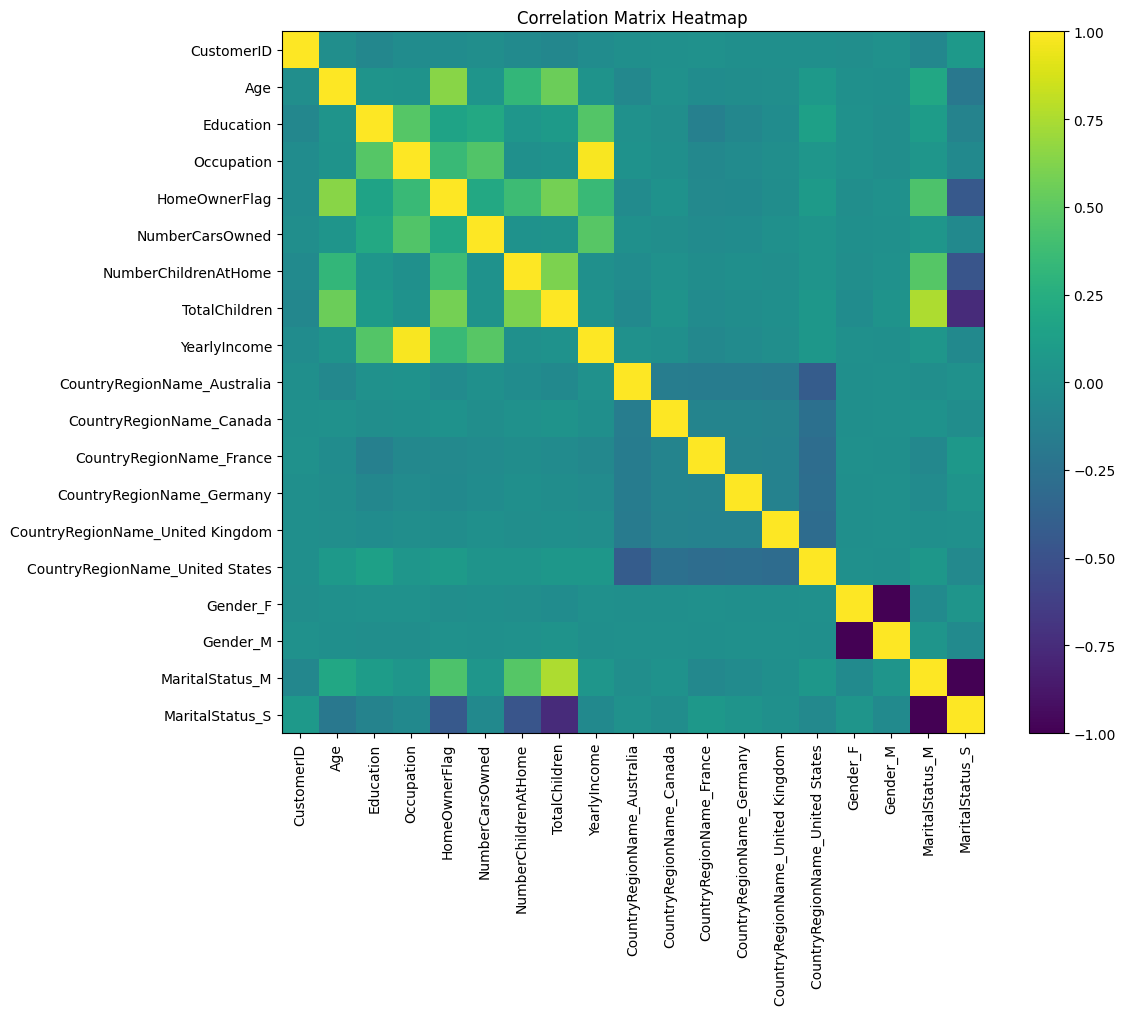

In [32]:
import matplotlib.pyplot as plt
import numpy as np

corr = correlation_matrix

plt.figure(figsize=(12, 10))

plt.imshow(corr, interpolation='nearest')
plt.colorbar()

# Add labels
plt.xticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr.columns)), labels=corr.columns)

plt.title("Correlation Matrix Heatmap")

plt.tight_layout()
plt.show()